## HR Diagram

Define the needed functions

In [7]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from matplotlib import pyplot as plt
import urllib.request
from sklearn import preprocessing

def perform_pca(data,number_of_components = None):
    pca = PCA(number_of_components)
    projecteddata = pca.fit_transform(data)
    n_components = pca.n_components_
    evariance = pca.explained_variance_
    evarianceratio = pca.explained_variance_ratio_
    components = pca.components_
    fig = plt.figure(figsize=(7, 7))
    projecteddata = pd.DataFrame(projecteddata,columns=[f'EV{i+1}' for i in range(n_components)])
    sns.scatterplot(data=projecteddata.iloc[:,0:2], x='EV1', y='EV2', hue=labels)
    
    # Plot the results
    fig = plt.figure(figsize=(10, 3))
    ax = fig.add_subplot(121)
    ax.plot(np.arange(n_components), evarianceratio)
    ax.scatter(np.arange(n_components), evarianceratio)
    ax.set_xlabel("eigenvalue")
    ax.set_ylabel("explained variance ratio")

    ax = fig.add_subplot(122)
    ax.plot(np.arange(n_components), evarianceratio.cumsum())
    ax.scatter(np.arange(n_components), evarianceratio.cumsum())
    ax.set_xlabel("eigenvalue number")
    ax.set_ylabel("cumulative explained variance ratio")
    
    print('Eigenvectors')
    for component in components:
     print(" + ".join("%.3f x %s" % (value, name) for value, name in
     zip(component, columns)))
    plt.show()
    return pca


Load the data and check if there is nan of null values

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']

Check quickly if any null value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int32  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int32(1), int64(1), object(2)
memory usage: 12.3+ KB

Check quickly the NOT NA value

Temperature (K)           240
Luminosity(L/Lo)          240
Radius(R/Ro)              240
Absolute magnitude(Mv)    240
Star type                 240
Star color                240
Spectral Class

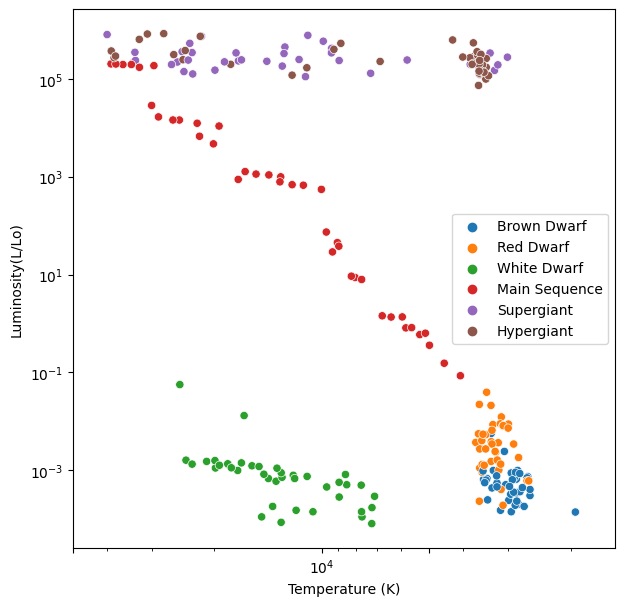

In [3]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
df_stars = pd.read_csv("stars.csv")

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

print('\nCheck quickly if any null value\n')
df_stars.info()
print('\nCheck quickly the NOT NA value\n')
print(df_stars.notna().count())

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)
plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

Take the first 4 columns and perform pca

Eigenvectors
0.021 x Temperature (K) + 1.000 x Luminosity(L/Lo) + 0.002 x Radius(R/Ro) + -0.000 x Absolute magnitude(Mv)
1.000 x Temperature (K) + -0.021 x Luminosity(L/Lo) + -0.009 x Radius(R/Ro) + -0.000 x Absolute magnitude(Mv)
0.009 x Temperature (K) + -0.002 x Luminosity(L/Lo) + 1.000 x Radius(R/Ro) + -0.008 x Absolute magnitude(Mv)
0.000 x Temperature (K) + 0.000 x Luminosity(L/Lo) + 0.008 x Radius(R/Ro) + 1.000 x Absolute magnitude(Mv)


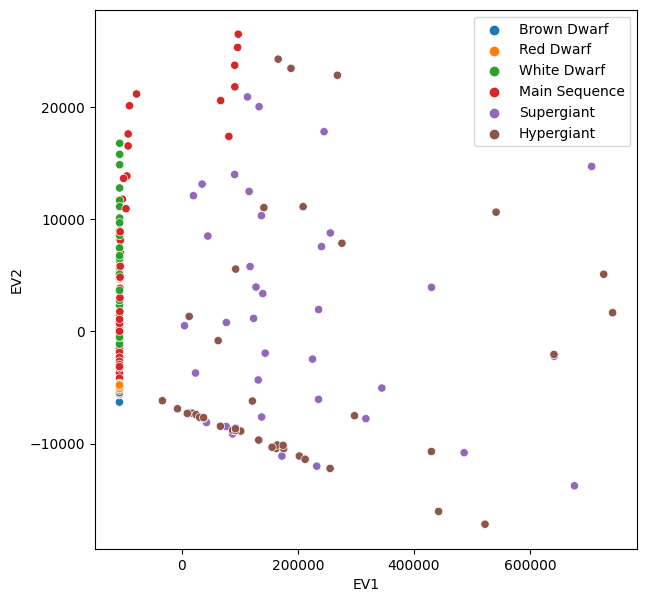

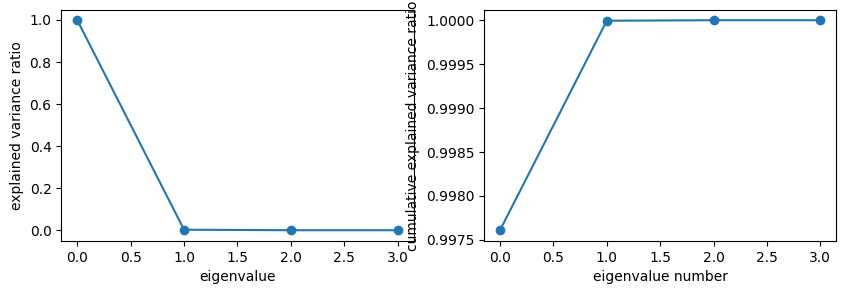

PCA()

In [8]:
columns = df_stars.columns[:4]

perform_pca(df_stars[columns])


Use the standard scale

Eigenvectors
0.350 x Temperature (K) + 0.559 x Luminosity(L/Lo) + 0.475 x Radius(R/Ro) + -0.582 x Absolute magnitude(Mv)
0.822 x Temperature (K) + 0.005 x Luminosity(L/Lo) + -0.569 x Radius(R/Ro) + 0.035 x Absolute magnitude(Mv)
-0.376 x Temperature (K) + 0.755 x Luminosity(L/Lo) + -0.533 x Radius(R/Ro) + 0.064 x Absolute magnitude(Mv)
0.247 x Temperature (K) + 0.342 x Luminosity(L/Lo) + 0.408 x Radius(R/Ro) + 0.810 x Absolute magnitude(Mv)


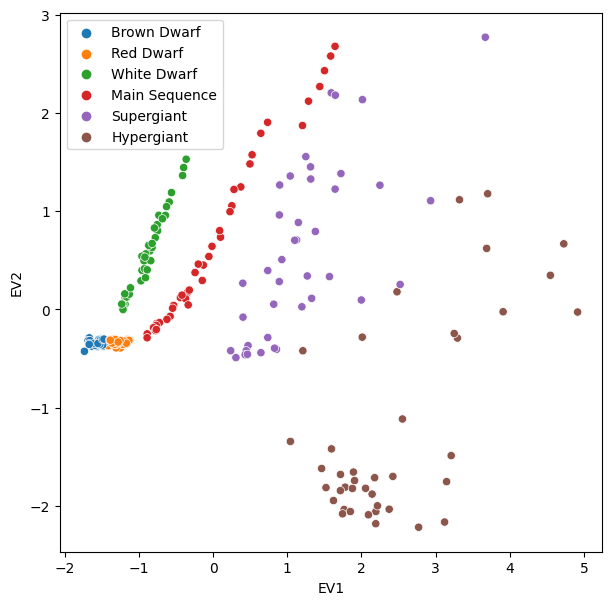

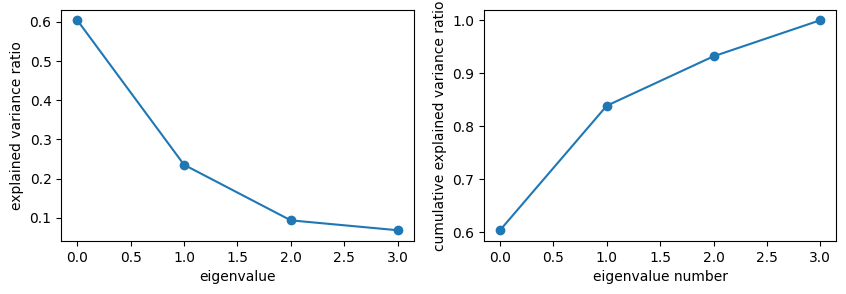

PCA()

In [9]:
scaler = preprocessing.StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df_stars[columns]),columns = columns)
perform_pca(scaled_df)


use the maxmin scaler that seems to perform a little better

Eigenvectors
0.299 x Temperature (K) + 0.400 x Luminosity(L/Lo) + 0.464 x Radius(R/Ro) + -0.732 x Absolute magnitude(Mv)
0.816 x Temperature (K) + 0.036 x Luminosity(L/Lo) + -0.576 x Radius(R/Ro) + -0.012 x Absolute magnitude(Mv)
0.470 x Temperature (K) + -0.016 x Luminosity(L/Lo) + 0.651 x Radius(R/Ro) + 0.596 x Absolute magnitude(Mv)
-0.154 x Temperature (K) + 0.916 x Luminosity(L/Lo) + -0.169 x Radius(R/Ro) + 0.330 x Absolute magnitude(Mv)


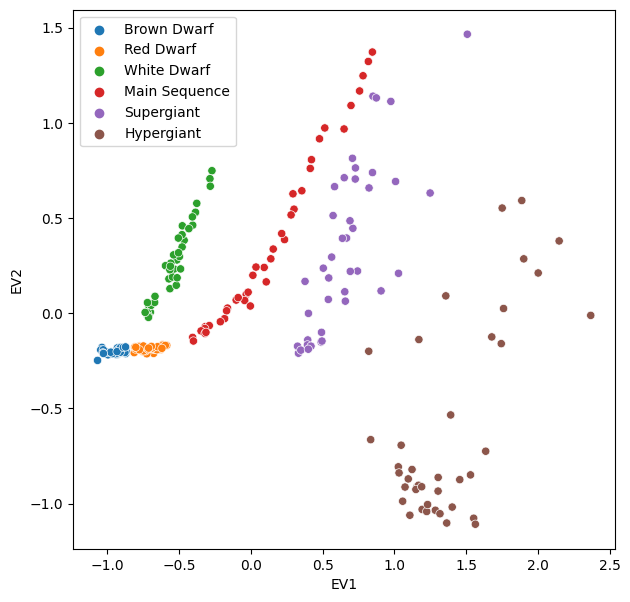

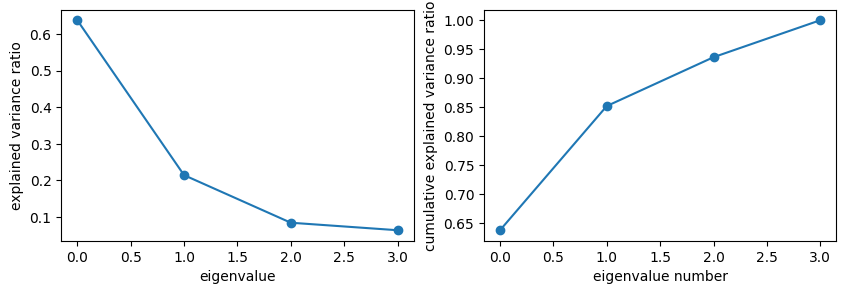

PCA()

In [10]:
scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
scaled_df = pd.DataFrame(scaler.fit_transform(df_stars[columns]),columns = columns)
perform_pca(scaled_df)
